In [ ]:
import os

from google.colab import drive
drive.mount('/content/drive')

In [ ]:
!git clone https://github.com/jasonfghx/Medical-voice-recognition_processing_system.git

Cloning into 'Medical-voice-recognition_processing_system'...
remote: Enumerating objects: 2704, done.
remote: Counting objects: 100% (608/608), done.
remote: Compressing objects: 100% (575/575), done.
remote: Total 2704 (delta 84), reused 340 (delta 33), pack-reused 2096 (from 1)
Receiving objects: 100% (2704/2704), 973.32 MiB | 15.66 MiB/s, done.
Resolving deltas: 100% (365/365), done.
Updating files: 100% (2376/2376), done.


In [ ]:
from glob import glob
import random
import json
Negative=glob("/content/Medical-voice-recognition_processing_system/cough/Negative/*.wav")
temp=[]
for i in Negative:
  json_temp={'audio_filepath':i,
        'duration':2,
        'label':'n',
        'text':'_',
        'offset':0}
  temp.append(json_temp)
Positive=glob("/content/Medical-voice-recognition_processing_system/cough/Positive/*.wav")
for i in Positive*10:
  json_temp={'audio_filepath':i,
        'duration':2,
        'label':'p',
        'text':'_',
        'offset':0}
  temp.append(json_temp)

random.shuffle(temp)
train_temp=temp[:int(len(temp)*0.8)]
test_temp=temp[int(len(temp)*0.8):int(len(temp)*0.9)+1]
val_temp=temp[int(len(temp)*0.9):]
with open('/content/train.json', 'w') as f:
  for i in train_temp:
    json.dump(i, f)
    f.write('\n')
with open('/content/test.json', 'w') as f:
  for i in test_temp:
    json.dump(i, f)
    f.write('\n')
with open('/content/val.json', 'w') as f:
  for i in val_temp:
    json.dump(i, f)
    f.write('\n')

In [ ]:
from glob import glob
import json
Negative=glob("/content/Medical-voice-recognition_processing_system/cough/Negative/*.wav")
temp=[]
for i in Negative:
  json_temp={'audio_filepath':'/content/Medical-voice-recognition_processing_system/background/white_noise.wav',
        'duration':2,
        'label':'n',
        'text':'_',
        'offset':0}
  temp.append(json_temp)
Positive=glob("/content/Medical-voice-recognition_processing_system/cough/Positive/*.wav")
for i in Positive*10:
  json_temp={'audio_filepath':'/content/Medical-voice-recognition_processing_system/background/white_noise.wav',
        'duration':2,
        'label':'p',
        'text':'_',
        'offset':0}
  temp.append(json_temp)
train_temp=temp[:int(len(temp)*0.8)]
test_temp=temp[int(len(temp)*0.8):int(len(temp)*0.9)+1]
val_temp=temp[int(len(temp)*0.9):]
with open('/content/train_background.json', 'w') as f:
  for i in train_temp:
    json.dump(i, f)
    f.write('\n')
with open('/content/test_background.json', 'w') as f:
  for i in test_temp:
    json.dump(i, f)
    f.write('\n')
with open('/content/val_background.json', 'w') as f:
  for i in val_temp:
    json.dump(i, f)
    f.write('\n')
#

In [ ]:
!pip install wget
!apt-get install sox libsndfile1 ffmpeg
!pip install text-unidecode

# ## Install NeMo
BRANCH = 'main'
!python -m pip install git+https://github.com/NVIDIA/NeMo.git@$BRANCH#egg=nemo_toolkit[asr]

## Install TorchAudio
!pip install torchaudio>=0.13.0 -f https://download.pytorch.org/whl/torch_stable.html

## Grab the config we'll use in this example
!mkdir configs

In [ ]:
import numpy as np
import os
from omegaconf import OmegaConf
import pyaudio as pa
import os, time
import nemo
import nemo.collections.asr as nemo_asr
# tmp = 'src'
# data_folder = 'data'
# if not os.path.exists(tmp):
#     os.makedirs(tmp)
# if not os.path.exists(data_folder):
#     os.makedirs(data_folder)
# script = os.path.join(tmp, 'process_vad_data.py')
# if not os.path.exists(script):
#     !wget -P $tmp https://raw.githubusercontent.com/NVIDIA/NeMo/$BRANCH/scripts/dataset_processing/process_vad_data.py

In [ ]:
# speech_data_root = os.path.join(data_folder, 'google_dataset_v2')
# background_data_root = os.path.join(data_folder, 'google_dataset_v2/google_speech_recognition_v2/_background_noise_')# your <resampled freesound data directory>
# out_dir = os.path.join(data_folder, 'manifest')
# if not os.path.exists(speech_data_root):
#     os.mkdir(speech_data_root)

In [ ]:
# !python $script \
#     --out_dir={out_dir} \
#     --speech_data_root={speech_data_root} \
#     --background_data_root={background_data_root}\
#     --log \
#     --demo \
#     --rebalance_method='fixed'

In [ ]:
# change below if you don't have or don't want to use rebalanced data
train_dataset = 'data/manifest/balanced_background_training_manifest.json,data/manifest/balanced_speech_training_manifest.json'
val_dataset = 'data/manifest/background_validation_manifest.json,data/manifest/speech_validation_manifest.json'
test_dataset = 'data/manifest/balanced_background_testing_manifest.json,data/manifest/balanced_speech_testing_manifest.json'

In [ ]:
train_dataset = '/content/train_background.json,/content/train.json'
val_dataset = '/content/test_background.json,/content/test.json'
test_dataset = '/content/val_background.json,/content/val.json'

In [ ]:
sample_test_dataset =  test_dataset.split(',')[0]
!head -n 5 {sample_test_dataset}

{"audio_filepath": "/content/Medical-voice-recognition_processing_system/background/white_noise.wav", "duration": 2, "label": "p", "text": "_", "offset": 0}
{"audio_filepath": "/content/Medical-voice-recognition_processing_system/background/white_noise.wav", "duration": 2, "label": "p", "text": "_", "offset": 0}
{"audio_filepath": "/content/Medical-voice-recognition_processing_system/background/white_noise.wav", "duration": 2, "label": "p", "text": "_", "offset": 0}
{"audio_filepath": "/content/Medical-voice-recognition_processing_system/background/white_noise.wav", "duration": 2, "label": "p", "text": "_", "offset": 0}
{"audio_filepath": "/content/Medical-voice-recognition_processing_system/background/white_noise.wav", "duration": 2, "label": "p", "text": "_", "offset": 0}


In [ ]:
# NeMo's "core" package
import nemo
# NeMo's ASR collection - this collections contains complete ASR models and
# building blocks (modules) for ASR
import nemo.collections.asr as nemo_asr
MODEL_CONFIG = "marblenet_3x2x64.yaml"

if not os.path.exists(f"configs/{MODEL_CONFIG}"):

  !wget -P configs/ "https://raw.githubusercontent.com/NVIDIA/NeMo/$BRANCH/examples/asr/conf/marblenet/{MODEL_CONFIG}"

In [ ]:
config_path = f"configs/{MODEL_CONFIG}"
config = OmegaConf.load(config_path)
config = OmegaConf.to_container(config, resolve=True)
config = OmegaConf.create(config)

print(OmegaConf.to_yaml(config))


In [ ]:
config.model.labels

['background', 'speech']

\

In [ ]:
labels = config.model.labels
sample_rate = config.model.sample_rate

In [ ]:
print(OmegaConf.to_yaml(config.model.train_ds))

In [ ]:
print(OmegaConf.to_yaml(config.model.train_ds))

In [ ]:
config.model.labels=['p','n']
config.model.train_ds.labels=['p','n']
config.model.validation_ds.labels=['p','n']
config.model.test_ds.labels=['p','n']
config.model.train_ds.manifest_filepath = train_dataset
config.model.validation_ds.manifest_filepath = val_dataset
config.model.test_ds.manifest_filepath = test_dataset

In [ ]:
import torch
import pytorch_lightning as pl


In [ ]:
print("Trainer config - \n")
print(OmegaConf.to_yaml(config.trainer))

Trainer config - 

devices: 1
max_epochs: 150
max_steps: -1
num_nodes: 1
accelerator: gpu
strategy: ddp
accumulate_grad_batches: 1
enable_checkpointing: false
logger: false
log_every_n_steps: 1
val_check_interval: 1.0
benchmark: false



In [ ]:
accelerator = 'gpu' if torch.cuda.is_available() else 'cpu'
config.trainer.devices = 1
config.trainer.accelerator = accelerator

# Reduces maximum number of epochs to 5 for quick demonstration
config.trainer.max_epochs = 5

# Remove distributed training flags
config.trainer.strategy = 'auto'

In [ ]:
trainer = pl.Trainer(**config.trainer)

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.utilities.rank_zero:`Trainer(val_check_interval=1.0)` was configured so validation will run at the end of the training epoch..


In [ ]:
from nemo.utils.exp_manager import exp_manager
exp_dir = exp_manager(trainer, config.get("exp_manager", None))

[NeMo I 2024-11-19 06:50:17 exp_manager:450] ExpManager schema
[NeMo I 2024-11-19 06:50:17 exp_manager:451] {'explicit_log_dir': None, 'exp_dir': None, 'name': None, 'version': None, 'use_datetime_version': True, 'resume_if_exists': False, 'resume_past_end': False, 'resume_ignore_no_checkpoint': False, 'resume_from_checkpoint': None, 'create_tensorboard_logger': True, 'summary_writer_kwargs': None, 'create_wandb_logger': False, 'wandb_logger_kwargs': None, 'create_mlflow_logger': False, 'mlflow_logger_kwargs': {'experiment_name': None, 'tracking_uri': None, 'tags': None, 'save_dir': './mlruns', 'prefix': '', 'artifact_location': None, 'run_id': None, 'log_model': False}, 'create_dllogger_logger': False, 'dllogger_logger_kwargs': {'verbose': False, 'stdout': False, 'json_file': './dllogger.json'}, 'create_clearml_logger': False, 'clearml_logger_kwargs': {'project': None, 'task': None, 'connect_pytorch': False, 'model_name': None, 'tags': None, 'log_model': False, 'log_cfg': False, 'log_

In [ ]:
exp_dir = str(exp_dir)
exp_dir

'/content/nemo_experiments/MarbleNet-3x2x64/2024-11-19_06-28-07'

In [ ]:
!pip list

In [ ]:
vad_model = nemo_asr.models.EncDecClassificationModel(cfg=config.model, trainer=trainer)


ValueError: trainer constructor argument must be either None or lightning.pytorch.Trainer. But got <class 'pytorch_lightning.trainer.trainer.Trainer'> instead.

In [ ]:

trainer.fit(vad_model)
trainer.test(vad_model, ckpt_path=None)

TypeError: `model` must be a `LightningModule` or `torch._dynamo.OptimizedModule`, got `EncDecClassificationModel`

In [ ]:
vad_model.setup_test_data(config.model.test_ds)
test_dl = vad_model._test_dl

{'audio_file': 'data/google_dataset_v2/google_speech_recognition_v2/_background_noise_more/white_noise.wav_800000.wav', 'duration': 2, 'label': 'n', 'offset': 0, 'id': 0}
{'audio_file': 'data/google_dataset_v2/google_speech_recognition_v2/_background_noise_more/white_noise.wav_800000.wav', 'duration': 2, 'label': 'n', 'offset': 0, 'id': 1}
{'audio_file': 'data/google_dataset_v2/google_speech_recognition_v2/_background_noise_more/white_noise.wav_800000.wav', 'duration': 2, 'label': 'n', 'offset': 0, 'id': 2}
{'audio_file': 'data/google_dataset_v2/google_speech_recognition_v2/_background_noise_more/white_noise.wav_800000.wav', 'duration': 2, 'label': 'n', 'offset': 0, 'id': 3}
{'audio_file': 'data/google_dataset_v2/google_speech_recognition_v2/_background_noise_more/white_noise.wav_800000.wav', 'duration': 2, 'label': 'n', 'offset': 0, 'id': 4}
{'audio_file': 'data/google_dataset_v2/google_speech_recognition_v2/_background_noise_more/white_noise.wav_800000.wav', 'duration': 2, 'label': '

In [ ]:
@torch.no_grad()
def extract_logits(model, dataloader):
    logits_buffer = []
    label_buffer = []

    # Follow the above definition of the test_step
    for batch in dataloader:
        audio_signal, audio_signal_len, labels, labels_len = batch
        logits = model(input_signal=audio_signal, input_signal_length=audio_signal_len)

        logits_buffer.append(logits)
        label_buffer.append(labels)
        print(".", end='')
    print()

    print("Finished extracting logits !")
    logits = torch.cat(logits_buffer, 0)
    labels = torch.cat(label_buffer, 0)
    return logits, labels

In [ ]:
cpu_model = vad_model.cpu()
cpu_model.eval()
logits, labels = extract_logits(cpu_model, test_dl)
print("Logits:", logits.shape, "Labels :", labels.shape)

...............
Finished extracting logits !
Logits: torch.Size([1914, 2]) Labels : torch.Size([1914])


In [ ]:
# Compute accuracy - `_accuracy` is a PyTorch Lightning Metric !
acc = cpu_model._accuracy(logits=logits, labels=labels)
print(f"Accuracy : {float(acc[0]*100)} %")

Accuracy : 91.64054107666016 %


In [ ]:
# 0730
import pandas as pd

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
from sklearn.ensemble import RandomForestRegressor,RandomForestClassifier
from sklearn.inspection import permutation_importance
a=pd.read_csv('/content/drive/MyDrive/程式/0726test.csv')
def ch1(a):
  if a==1:
    return 1
  else:
    return 0
def ch2(a):
  if a==0:
    return 1
  else:
    return 0
def AGE_l_60(a):
  if a>=60:
    return 0
  else:
    return 1
def AGE_s_60(a):
  if a<60:
    return 0
  else:
    return 1

a['SEX_0']=a['SEX'].apply(ch1)
a['SEX_1']=a['SEX'].apply(ch2)
a['AGE_l_60']=a['AGE'].apply(AGE_l_60)
a['AGE_s_60']=a['AGE'].apply(AGE_s_60)
a['AGE_s60*SEX_0']=a['AGE_s_60']*a['SEX_0']
a['AGE_s60*SEX_1']=a['AGE_s_60']*a['SEX_1']
a['AGE_l60*SEX_0']=a['AGE_l_60']*a['SEX_0']
a['AGE_l60*SEX_1']=a['AGE_l_60']*a['SEX_1']



In [ ]:
a.to_csv('1.csv',index=False)

In [ ]:
a.columns

Index(['AGE', 'SEX', 'NAFLD_new', 'SEX_0', 'SEX_1', 'AGE_l_60', 'AGE_s_60',
       'AGE_s60*SEX_0', 'AGE_s60*SEX_1', 'AGE_l60*SEX_0', 'AGE_l60*SEX_1'],
      dtype='object')

In [ ]:
a['AGE_l60*SEX_0'].value_counts()

0    82194
1    59218
Name: AGE_l60*SEX_0, dtype: int64

In [ ]:
a['AGE_l60*SEX_0'].value_counts()

0    82194
1    59218
Name: AGE_l60*SEX_0, dtype: int64

In [ ]:
X = a[['AGE','SEX','AGE_s60*SEX_0','AGE_s60*SEX_1','AGE_l60*SEX_0','AGE_l60*SEX_1']].values # 使用六組參數 ACC最差
y = a['NAFLD_new'].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.8, random_state=49, stratify=y)
logisticModel = LogisticRegression(C = 0.1,multi_class='auto',  penalty= 'l1',solver='liblinear',random_state=10)
# 使用訓練資料訓練模型
logisticModel.fit(X_train, y_train)
# 使用訓練資料預測分類
predicted = logisticModel.predict(X_train)
print('訓練集: ',logisticModel.score(X_train,y_train))

訓練集:  0.6487518563043632


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
X = a[['AGE','SEX','AGE_l60*SEX_0','AGE_l60*SEX_1']].values # 使用四組 ACC最佳
y = a['NAFLD_new'].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.8, random_state=49, stratify=y)
logisticModel = LogisticRegression(C = 0.1,multi_class='auto',  penalty= 'l2',solver='liblinear',random_state=210)
# 使用訓練資料訓練模型
logisticModel.fit(X_train, y_train)
# 使用訓練資料預測分類
predicted = logisticModel.predict(X_train)
print('訓練集: ',logisticModel.score(X_test,y_test))

訓練集:  0.6573587907716786


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
X = a[['AGE','SEX']].values # 移除Species並取得剩下欄位資料
y = a['NAFLD_new'].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.8, random_state=49, stratify=y)
logisticModel = LogisticRegression(C = 0.1,multi_class='auto',  penalty= 'l2',solver='liblinear',random_state=210)
# 使用訓練資料訓練模型
logisticModel.fit(X_train, y_train)
# 使用訓練資料預測分類
predicted = logisticModel.predict(X_train)
print('訓練集: ',logisticModel.score(X_test,y_test))

訓練集:  0.6505524617696455


In [ ]:
X_train.shape

(113129, 6)

In [ ]:
import eli5
eli5.show_weights(logisticModel, top=-1, feature_names = ['AGE','SEX','AGE_s60*SEX_0','AGE_s60*SEX_1','AGE_l60*SEX_0','AGE_l60*SEX_1'])

ValueError: ignored

In [ ]:
import eli5
eli5.show_weights(logisticModel, top=-1, feature_names = ['AGE','SEX','AGE_l60*SEX_0','AGE_l60*SEX_1'])

Weight?,Feature
+1.287,AGE_l60*SEX_0
+0.044,AGE
-0.111,AGE_l60*SEX_1
-2.672,<BIAS>


In [ ]:
!git clone https://github.com/jasonfghx/spectrum.git

Cloning into 'spectrum'...
remote: Enumerating objects: 189, done.
remote: Counting objects: 100% (189/189), done.
remote: Compressing objects: 100% (181/181), done.
remote: Total 189 (delta 72), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (189/189), 443.74 KiB | 1.77 MiB/s, done.
Resolving deltas: 100% (72/72), done.


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
a=pd.read_csv('/content/spectrum/spectrum.csv')

In [ ]:
a.shape

(202, 407)

In [ ]:
np.array(a.iloc[0,1:-6].values.reshape(20,20)*255,dtype=float)

In [ ]:
a.iloc[107,0:1]

,107
Var1_1,square_Wx_120.0_Wy_120.0_h_700.0


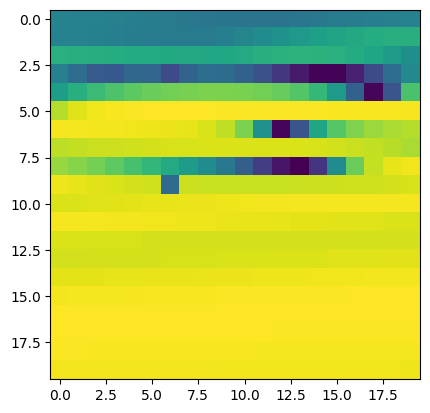

In [ ]:
# plt.imshow()
plt.imshow(np.array(a.iloc[170,1:-6].values.reshape(20,20)*255,dtype=float), cmap='viridis', interpolation='nearest')

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from glob import glob
import time
import cv2
import tensorflow as tf
from tensorflow import keras
from keras import Sequential
from keras.models import Model
from keras.layers import Conv2D, Input, MaxPool2D, Conv2DTranspose, concatenate, Lambda, BatchNormalization, Activation, LeakyReLU, ReLU
from keras.utils import img_to_array, load_img, plot_model
from keras.optimizers import Adam
from keras.initializers import RandomNormal

In [ ]:
len(glob('/content/spectrum/image1/*'))

200

In [ ]:
path = '/content/spectrum/image1'
num_images = 200

color_paths = sorted(glob(path + "/" + "*.png"))
images = np.zeros(shape=(len(color_paths), 64, 64, 3))
masks = np.zeros(shape=(len(color_paths), 64, 64, 3))


for i in range(0,num_images):
  image = tf.cast(img_to_array(load_img(color_paths[i])), tf.float32)
  temp=color_paths[i].replace('/content/spectrum/image1/','').replace(".png",'')
  temp_df=a[a['Var1_1']==temp]
  temp_image=np.array(temp_df.iloc[0,1:-6].values.reshape(20,20)*255,dtype=float)
  input1 = tf.cast(img_to_array(temp_image), tf.float32)

  images[i] = (tf.image.resize(image,(64,64)))/255.
  masks[i] = (tf.image.resize(input1,(64,64)))/255.



In [ ]:
len(masks)

200

In [ ]:
plt.figure(figsize=(25,10))
for i in range(180,185):
    image, mask = images[i], masks[i]
    plt.subplot(2,5,i-179)
    plt.imshow(image,cmap='gray')
    plt.title("image " + str(i))
    plt.axis("off")

    plt.subplot(2,5,i-179 + 5)
    plt.imshow(mask,cmap='gray')
    plt.title("B&W image " + str(i))
    plt.axis("off")
plt.show()

/usr/local/lib/python3.10/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


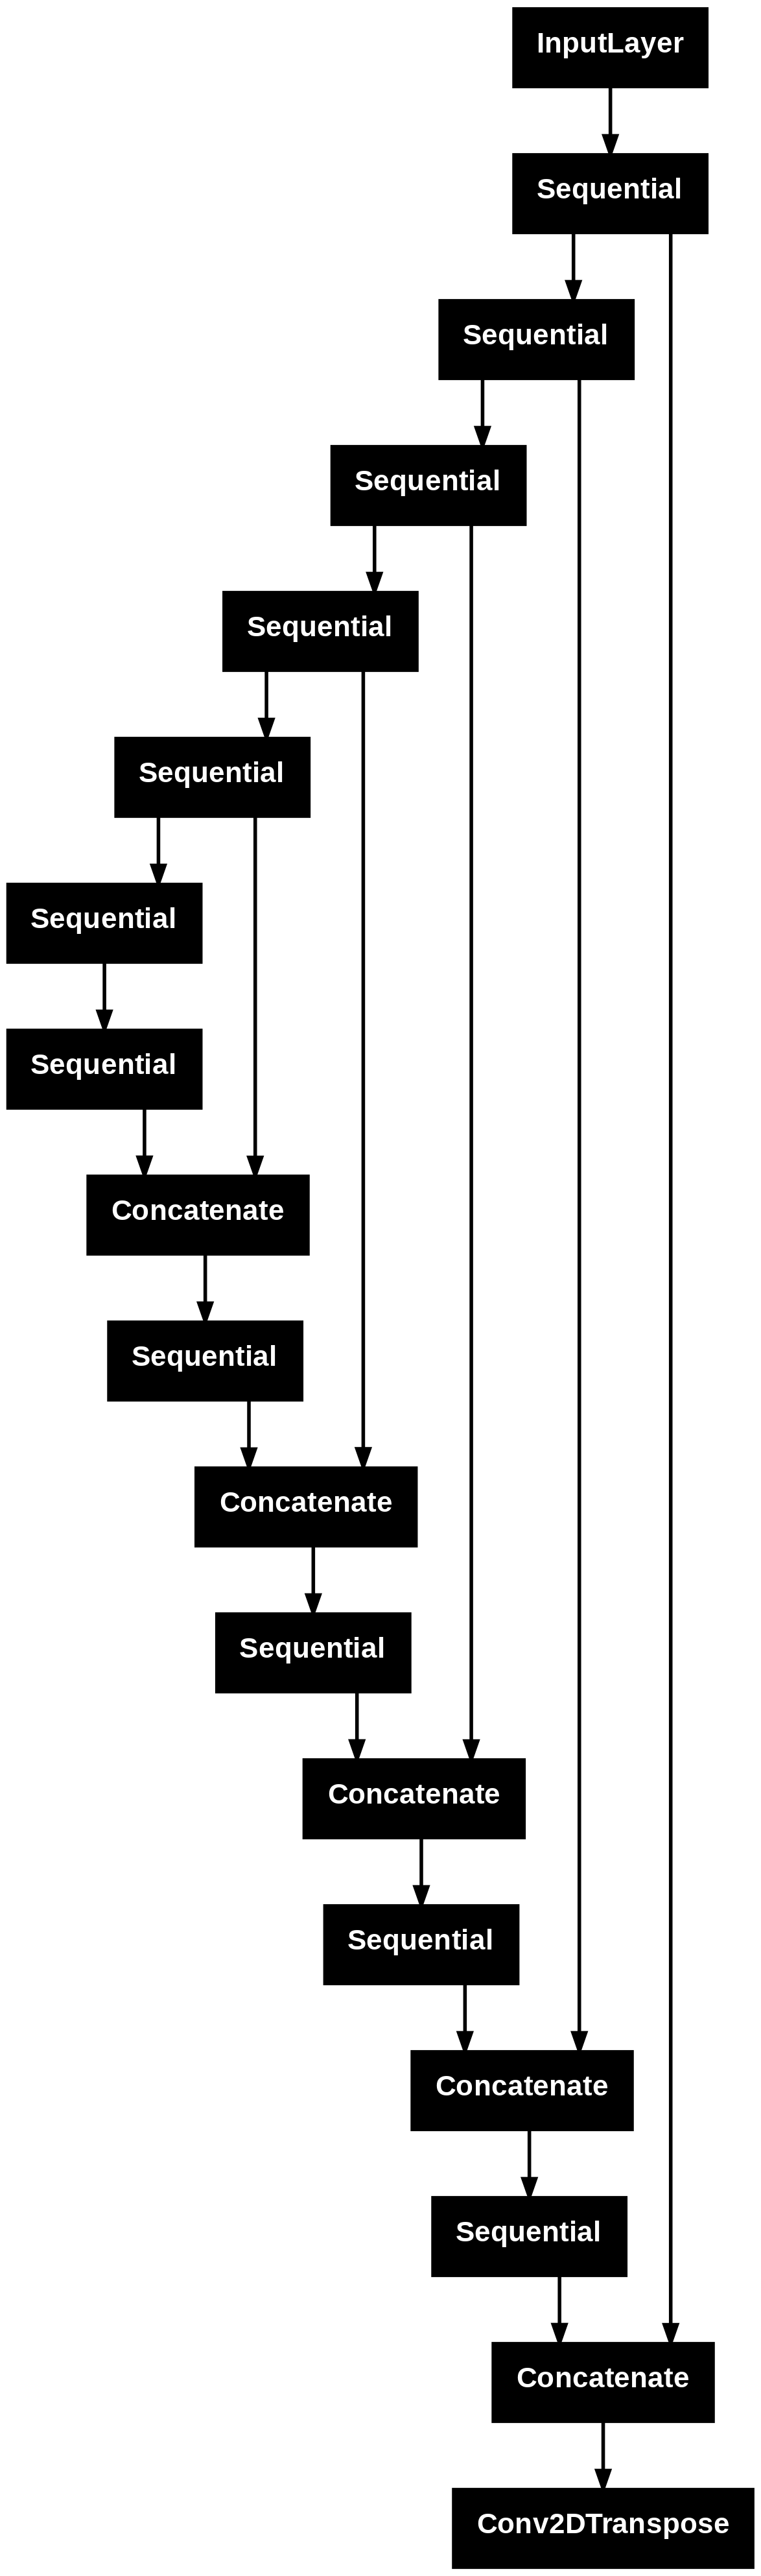

In [ ]:
def downscale(num_filters):
    block = Sequential()
    block.add(Conv2D(num_filters, kernel_size=4, strides=2, padding='same', kernel_initializer='he_normal', use_bias=False))
    block.add(LeakyReLU(alpha=0.2))
    block.add(BatchNormalization())
    return block

def upscale(num_filters):
    block = Sequential()
    block.add(Conv2DTranspose(num_filters, kernel_size=4, strides=2, padding='same', kernel_initializer='he_normal', use_bias=False))
    block.add(LeakyReLU(alpha=0.2))
    block.add(BatchNormalization())
    block.add(ReLU())
    return block

def Generator():
    inputs = Input(shape=(64,64,3), name="InputLayer")

    encoder = [
        downscale(64),
        downscale(128),
        downscale(256),
        downscale(256),
        downscale(256),
        # downscale(512),
        # downscale(512),
        # downscale(512),
        # downscale(512),
    ]

    latent_space = downscale(256)

    decoder = [
        # upscale(512),
        # upscale(512),
        # upscale(512),
        # upscale(512),
        upscale(256),
        upscale(256),
        upscale(256),
        upscale(128),
        upscale(64),
    ]

    x = inputs
    skips = []
    for layer in encoder:
        x = layer(x)
        skips.append(x)

    x = latent_space(x)

    skips = reversed(skips)
    for up, skip in zip(decoder, skips):
        x = up(x)
        x = concatenate([x, skip])

    initializer = RandomNormal(stddev=0.02, seed=42)
    outputs = Conv2DTranspose(3, kernel_size=4, strides=2, kernel_initializer = initializer, activation = 'tanh', padding = 'same')

    outputs = outputs(x)

    generator = Model(inputs = inputs, outputs = outputs, name="Generator")
    return generator
generator = Generator()
plot_model(generator)

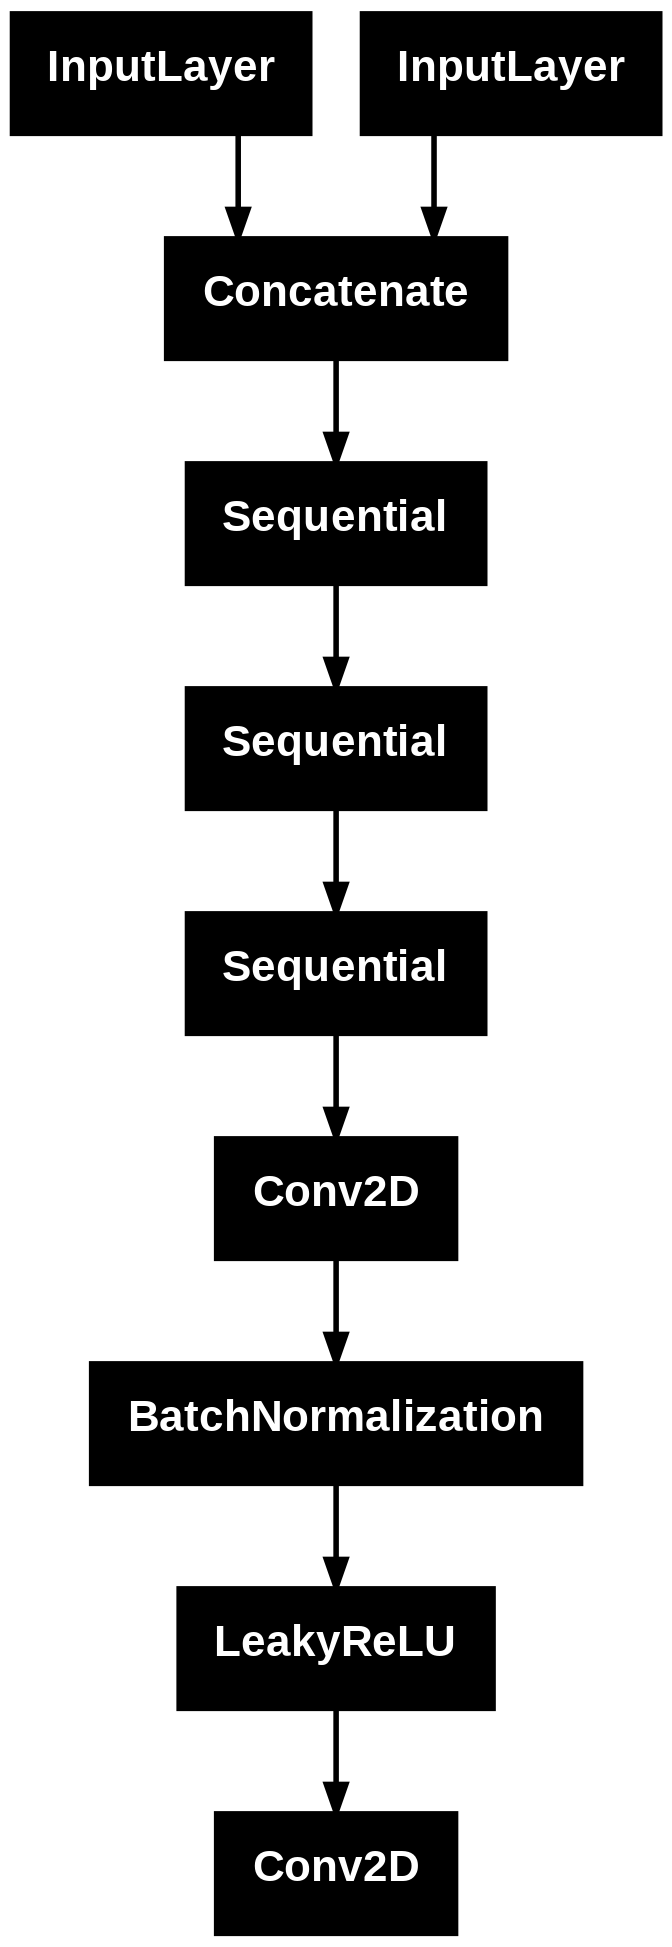

In [ ]:
def Discriminator():
    image = Input(shape = (64,64,3), name = "ImageInput")
    target = Input(shape = (64,64,3), name = "TargetInput")
    x = concatenate([image, target])

    x = downscale(64)(x)
    x = downscale(128)(x)
    x = downscale(512)(x)

    initializer = RandomNormal(stddev = 0.02, seed=42)

    x = Conv2D(512, kernel_size = 4, strides = 1, kernel_initializer = initializer, use_bias=False)(x)
    x = BatchNormalization()(x)
    x = LeakyReLU()(x)

    x = Conv2D(1, kernel_size = 4, kernel_initializer = initializer)(x)

    discriminator = Model(inputs = [image, target], outputs = x, name = "Discriminator")

    return discriminator
discriminator = Discriminator()
plot_model(discriminator)

In [ ]:
adversarial_loss = tf.keras.losses.BinaryCrossentropy(from_logits=True)
generator_optimizer = tf.keras.optimizers.Adam(2e-4, beta_1=0.5)
discriminator_optimizer = tf.keras.optimizers.Adam(2e-4, beta_1=0.5)

def generator_loss(discriminator_generated, generated_output, target_image):
    gan_loss = adversarial_loss(tf.ones_like(discriminator_generated), discriminator_generated)
    l1_loss = tf.reduce_mean(tf.abs(target_image - generated_output))
    total_loss = (100 * l1_loss) + gan_loss
    return total_loss, gan_loss, l1_loss

def discriminator_loss(discriminator_real_output, discriminator_generated_output):
    real_loss = adversarial_loss(tf.ones_like(discriminator_real_output), discriminator_real_output)
    fake_loss = adversarial_loss(tf.zeros_like(discriminator_generated_output), discriminator_generated_output)
    total_loss = real_loss + fake_loss
    return total_loss

def train_step(inputs, target):
    with tf.GradientTape() as generator_tape, tf.GradientTape() as discriminator_tape:
        generated_output = generator(inputs, training=True)

        discriminator_real_output = discriminator([inputs, target], training=True)
        discriminator_generated_output = discriminator([inputs, generated_output], training=True)

        generator_total_loss, generator_gan_loss, generator_l1_loss = generator_loss(discriminator_generated_output, generated_output, target)

        discriminator_Loss = discriminator_loss(discriminator_real_output, discriminator_generated_output)

    generator_gradients = generator_tape.gradient(generator_total_loss, generator.trainable_variables)
    generator_optimizer.apply_gradients(zip(generator_gradients, generator.trainable_variables))
    print('Loss:',discriminator_Loss)
    discriminator_gradients = discriminator_tape.gradient(discriminator_Loss, discriminator.trainable_variables)
    discriminator_optimizer.apply_gradients(zip(discriminator_gradients, discriminator.trainable_variables))
def fit(data, epochs):
  for epoch in range(epochs):
    start = time.time()
    print("Current epoch: ", epoch+1)
    for image, mask in data:
      train_step(image, mask)
    print(f"Time taken to complete the epoch {epoch + 1} is {(time.time() - start):.2f} seconds \n")
rgb, gray = tf.cast(images, tf.float32), tf.cast(masks, tf.float32)
dataset = (gray,rgb)
data = tf.data.Dataset.from_tensor_slices(dataset).batch(32, drop_remainder=True)
fit(data, 100)

Current epoch:  1
Loss: tf.Tensor(1.7650595, shape=(), dtype=float32)
Loss: tf.Tensor(0.7750629, shape=(), dtype=float32)
Loss: tf.Tensor(0.46458608, shape=(), dtype=float32)
Loss: tf.Tensor(0.45537618, shape=(), dtype=float32)
Loss: tf.Tensor(0.19628684, shape=(), dtype=float32)
Loss: tf.Tensor(0.43485868, shape=(), dtype=float32)
Time taken to complete the epoch 1 is 5.38 seconds 

Current epoch:  2
Loss: tf.Tensor(1.1759723, shape=(), dtype=float32)
Loss: tf.Tensor(0.63391626, shape=(), dtype=float32)
Loss: tf.Tensor(0.22240731, shape=(), dtype=float32)
Loss: tf.Tensor(0.51641864, shape=(), dtype=float32)
Loss: tf.Tensor(0.87267375, shape=(), dtype=float32)
Loss: tf.Tensor(1.4095129, shape=(), dtype=float32)
Time taken to complete the epoch 2 is 5.10 seconds 

Current epoch:  3
Loss: tf.Tensor(3.0153418, shape=(), dtype=float32)
Loss: tf.Tensor(0.55355364, shape=(), dtype=float32)
Loss: tf.Tensor(0.71421665, shape=(), dtype=float32)
Loss: tf.Tensor(0.43667588, shape=(), dtype=float3

KeyboardInterrupt: 

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step


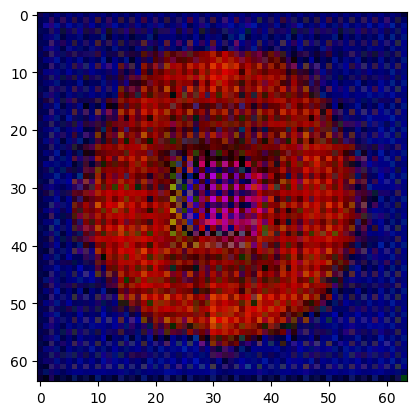

In [ ]:
idx = np.random.randint(images.shape[0])
image, mask = images[idx], masks[idx]
predicted = generator.predict(tf.expand_dims(image, axis=0))[0]
plt.imshow(predicted)

array([[[84,  1, 68],
        [84,  1, 68],
        [84,  1, 68],
        ...,
        [84,  1, 68],
        [84,  1, 68],
        [84,  1, 68]],

       [[84,  1, 68],
        [84,  1, 68],
        [84,  1, 68],
        ...,
        [84,  1, 68],
        [84,  1, 68],
        [84,  1, 68]],

       [[84,  1, 68],
        [84,  1, 68],
        [84,  1, 68],
        ...,
        [84,  1, 68],
        [84,  1, 68],
        [84,  1, 68]],

       ...,

       [[84,  1, 68],
        [84,  1, 68],
        [84,  1, 68],
        ...,
        [84,  1, 68],
        [84,  1, 68],
        [84,  1, 68]],

       [[84,  1, 68],
        [84,  1, 68],
        [84,  1, 68],
        ...,
        [84,  1, 68],
        [84,  1, 68],
        [84,  1, 68]],

       [[84,  1, 68],
        [84,  1, 68],
        [84,  1, 68],
        ...,
        [84,  1, 68],
        [84,  1, 68],
        [84,  1, 68]]], dtype=uint8)
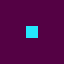

In [ ]:
cv2.imread(color_paths[idx])

In [ ]:
import cv2

image = cv2.imread(color_paths[idx])

blurred_image = cv2.GaussianBlur(image, (3, 3), 0)
plt.imshow(blurred_image)

array([[14, 14, 14, ..., 14, 14, 14],
       [14, 14, 14, ..., 14, 14, 14],
       [14, 14, 14, ..., 14, 14, 14],
       ...,
       [14, 14, 14, ..., 14, 14, 14],
       [14, 14, 14, ..., 14, 14, 14],
       [14, 14, 14, ..., 14, 14, 14]], dtype=uint8)
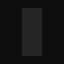

In [ ]:
image

In [ ]:
BRANCH = 'main'
if True:
    ## Install dependencies
    !pip install wget
    !apt-get install sox libsndfile1 ffmpeg
    !pip install text-unidecode

    ## Install NeMo
    !python -m pip install git+https://github.com/NVIDIA/NeMo.git@$BRANCH#egg=nemo_toolkit[all]

  Preparing metadata (setup.py) ... done
  Created wheel for wget: filename=wget-3.2-py3-none-any.whl size=9656 sha256=8887bf9893040547252ff1e0fa10451c75fb2d05501686ce06111376ea3f8660
  Stored in directory: /root/.cache/pip/wheels/8b/f1/7f/5c94f0a7a505ca1c81cd1d9208ae2064675d97582078e6c769
Successfully built wget
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
libsndfile1 is already the newest version (1.0.31-2ubuntu0.1).
ffmpeg is already the newest version (7:4.4.2-0ubuntu0.22.04.1).
The following additional packages will be installed:
  libopencore-amrnb0 libopencore-amrwb0 libsox-fmt-alsa libsox-fmt-base libsox3 libwavpack1
Suggested packages:
  libsox-fmt-all
The following NEW packages will be installed:
  libopencore-amrnb0 libopencore-amrwb0 libsox-fmt-alsa libsox-fmt-base libsox3 libwavpack1 sox
0 upgraded, 7 newly installed, 0 to remove and 49 not upgraded.
Need to get 617 kB of archives.
After this operation, 1,764 kB of additi

In [ ]:
import os
from pathlib import Path
import string
import tempfile

from omegaconf import OmegaConf
import pytorch_lightning as pl
import torch
from tqdm.auto import tqdm
import wget

from nemo.collections.asr.models import EncDecCTCModelBPE
from nemo.collections.asr.models.hybrid_asr_tts_models import ASRWithTTSModel
from nemo.collections.asr.parts.utils.manifest_utils import read_manifest, write_manifest
from nemo.collections.tts.models import FastPitchModel, SpectrogramEnhancerModel
from nemo.utils.notebook_utils import download_an4

try:
    from nemo_text_processing.text_normalization.normalize import Normalizer
except ModuleNotFoundError:
    raise ModuleNotFoundError(
        "The package `nemo_text_processing` was not installed in this environment. Please refer to"
        " https://github.com/NVIDIA/NeMo-text-processing and install this package before using "
        "this script"
    )
DATASETS_DIR = Path("./datasets")  # directory for data
CHECKPOINTS_DIR = Path("./checkpoints/")
DATASETS_DIR.mkdir(parents=True, exist_ok=True)
CHECKPOINTS_DIR.mkdir(parents=True, exist_ok=True)